# Métodos ensemble
### GCC1734 Inteligência Artificial · Companion da seção "Métodos ensemble"

Este notebook acompanha a seção `Métodos ensemble` das notas sobre Aprendizado de Máquina.

O foco aqui é tornar observáveis os pontos centrais do texto:

- **bagging** como redução de variância por votação entre modelos independentes;
- **Random Forest** como bagging com aleatoriedade adicional em atributos;
- **boosting** como construção sequencial voltada a corrigir erros do ensemble atual;
- **stacking** como combinação aprendida por um meta-modelo;
- comparação prática entre esses métodos em um problema realista.


In [1]:
# Configuração global
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml, make_classification, make_moons
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

RNG = np.random.default_rng(42)
np.set_printoptions(precision=3, suppress=True)


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


def make_bagging_classifier(estimator, **kwargs):
    try:
        return BaggingClassifier(estimator=estimator, **kwargs)
    except TypeError:
        return BaggingClassifier(base_estimator=estimator, **kwargs)


def make_adaboost_classifier(estimator, **kwargs):
    try:
        return AdaBoostClassifier(estimator=estimator, **kwargs)
    except TypeError:
        return AdaBoostClassifier(base_estimator=estimator, **kwargs)


def fetch_titanic_frame(data_home=None):
    candidates = []
    if data_home is not None:
        candidates.append(Path(data_home))
    candidates.extend([Path('src/am/data/sklearn_openml'), Path('data/sklearn_openml')])

    last_error = None
    for candidate in candidates:
        try:
            try:
                bunch = fetch_openml(name='titanic', version=1, as_frame=True, parser='auto', data_home=str(candidate))
            except TypeError:
                bunch = fetch_openml(name='titanic', version=1, as_frame=True, data_home=str(candidate))
            df = bunch.frame.copy()
            df['survived'] = df['survived'].astype(int)
            return df
        except Exception as exc:
            last_error = exc

    raise last_error


def evaluate_models(models, X_train, X_test, y_train, y_test):
    rows = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        if hasattr(model, 'predict_proba'):
            score = model.predict_proba(X_test)[:, 1]
        else:
            score = pred
        rows.append(
            {
                'modelo': name,
                'acurácia': accuracy_score(y_test, pred),
                'acurácia balanceada': balanced_accuracy_score(y_test, pred),
                'F1': f1_score(y_test, pred),
                'ROC AUC': roc_auc_score(y_test, score),
            }
        )
    return pd.DataFrame(rows).sort_values('ROC AUC', ascending=False)


---
## 1. Bagging: modelos independentes em paralelo

O texto enfatiza que árvores são instáveis: pequenas mudanças nos dados podem gerar modelos bem diferentes. Isso é exatamente o cenário em que **bagging** ajuda, porque ele treina vários modelos em amostras `bootstrap` e combina suas previsões.

Vamos comparar:

- uma árvore profunda isolada;
- `Bagging` com árvores profundas;
- `Random Forest`, que adiciona aleatoriedade nos atributos.


In [2]:
X, y = make_moons(n_samples=900, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, stratify=y, random_state=42
)

models_var = {
    'Árvore profunda': DecisionTreeClassifier(random_state=42),
    'Bagging': make_bagging_classifier(
        DecisionTreeClassifier(random_state=42),
        n_estimators=200,
        bootstrap=True,
        random_state=42,
        n_jobs=-1,
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1,
    ),
}

comparison_var = evaluate_models(models_var, X_train, X_test, y_train, y_test)
comparison_var


,modelo,acurácia,acurácia balanceada,F1,ROC AUC
2,Random Forest,0.914286,0.914234,0.912621,0.967044
1,Bagging,0.911111,0.911050,0.909091,0.959748
0,Árvore profunda,0.898413,0.898311,0.894737,0.898311


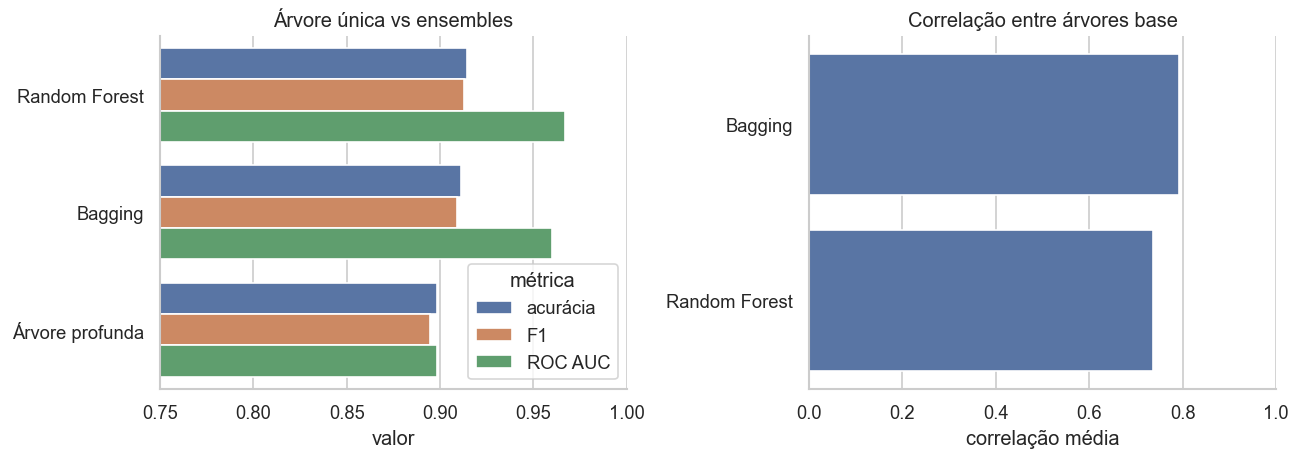

,ensemble,correlação média entre árvores
0,Bagging,0.793316
1,Random Forest,0.737541


In [3]:
# Bagging e Random Forest só funcionam se as árvores individuais não forem idênticas.
# Medimos essa diversidade pela correlação média das probabilidades produzidas por cada árvore.

bagging = models_var['Bagging'].fit(X_train, y_train)
rf = models_var['Random Forest'].fit(X_train, y_train)


def mean_pairwise_corr(estimators, X):
    probas = np.column_stack([est.predict_proba(X)[:, 1] for est in estimators])
    corr = np.corrcoef(probas, rowvar=False)
    upper = corr[np.triu_indices_from(corr, k=1)]
    return float(np.nanmean(upper))

corr_df = pd.DataFrame(
    [
        {
            'ensemble': 'Bagging',
            'correlação média entre árvores': mean_pairwise_corr(bagging.estimators_, X_test),
        },
        {
            'ensemble': 'Random Forest',
            'correlação média entre árvores': mean_pairwise_corr(rf.estimators_, X_test),
        },
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

plot_df = comparison_var.melt(
    id_vars='modelo',
    value_vars=['acurácia', 'F1', 'ROC AUC'],
    var_name='métrica',
    value_name='valor',
)
sns.barplot(data=plot_df, x='valor', y='modelo', hue='métrica', ax=axes[0])
axes[0].set(title='Árvore única vs ensembles', xlabel='valor', ylabel='')
axes[0].set_xlim(0.75, 1.0)

sns.barplot(data=corr_df, x='correlação média entre árvores', y='ensemble', ax=axes[1])
axes[1].set(title='Correlação entre árvores base', xlabel='correlação média', ylabel='')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

corr_df


A leitura esperada é a mesma das notas: `Bagging` reduz variância por média/votação; `Random Forest` costuma ir além porque reduz também a **correlação** entre árvores ao sortear subconjuntos de atributos em cada nó.


---
## 2. Boosting: modelos sequenciais que corrigem erros

No **boosting**, os modelos base não são independentes. Cada novo modelo tenta corrigir os exemplos mal previstos, ou os resíduos deixados, pelo ensemble parcial.

A comparação abaixo usa:

- um `stump` isolado (árvore de profundidade 1);
- `AdaBoost`, que repondera exemplos difíceis;
- `Gradient Boosting`, que ajusta modelos para corrigir resíduos.


In [4]:
Xb, yb = make_moons(n_samples=1000, noise=0.32, random_state=19)
Xb_train, Xb_temp, yb_train, yb_temp = train_test_split(
    Xb, yb, test_size=0.40, stratify=yb, random_state=19
)
Xb_val, Xb_test, yb_val, yb_test = train_test_split(
    Xb_temp, yb_temp, test_size=0.50, stratify=yb_temp, random_state=19
)

models_boost = {
    'Stump': DecisionTreeClassifier(max_depth=1, random_state=19),
    'AdaBoost': make_adaboost_classifier(
        DecisionTreeClassifier(max_depth=1, random_state=19),
        n_estimators=250,
        learning_rate=0.5,
        random_state=19,
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=180,
        learning_rate=0.05,
        max_depth=2,
        random_state=19,
    ),
}

comparison_boost = evaluate_models(models_boost, Xb_train, Xb_test, yb_train, yb_test)
comparison_boost


,modelo,acurácia,acurácia balanceada,F1,ROC AUC
1,AdaBoost,0.895,0.895,0.896552,0.95740
2,Gradient Boosting,0.895,0.895,0.898551,0.95555
0,Stump,0.780,0.780,0.775510,0.78000


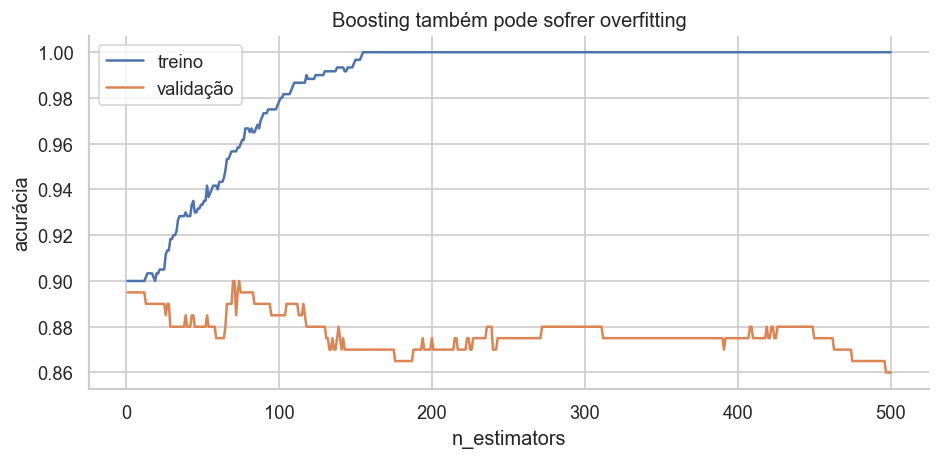

,iteração,acurácia treino,acurácia validação
73,74,0.958333,0.900
69,70,0.956667,0.900
70,71,0.956667,0.900
1,2,0.900000,0.895
82,83,0.965000,0.895


In [5]:
# O texto alerta que boosting também pode sofrer overfitting.
# Acompanhamos treino e validação ao longo das iterações do ensemble.

gb_overfit = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.15,
    max_depth=3,
    random_state=19,
)
gb_overfit.fit(Xb_train, yb_train)

rows = []
for i, (pred_train, pred_val) in enumerate(
    zip(gb_overfit.staged_predict(Xb_train), gb_overfit.staged_predict(Xb_val)),
    start=1,
):
    rows.append(
        {
            'iteração': i,
            'acurácia treino': accuracy_score(yb_train, pred_train),
            'acurácia validação': accuracy_score(yb_val, pred_val),
        }
    )

staged = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=staged, x='iteração', y='acurácia treino', label='treino', ax=ax)
sns.lineplot(data=staged, x='iteração', y='acurácia validação', label='validação', ax=ax)
ax.set(title='Boosting também pode sofrer overfitting', xlabel='n_estimators', ylabel='acurácia')
plt.tight_layout()
plt.show()

staged.sort_values('acurácia validação', ascending=False).head()


Esse gráfico deve reproduzir o ponto do `alertabox` das notas: boosting frequentemente reduz viés com eficiência, mas o ganho em validação pode saturar ou cair se o ensemble ficar agressivo demais.


---
## 3. Stacking: combinação aprendida de modelos

No **stacking**, a combinação não é fixa. Um **meta-modelo** aprende como combinar as previsões dos modelos base. Isso faz sentido quando os modelos têm comportamentos complementares.

As notas também alertam para **vazamento de informação**: o meta-modelo não deve ser treinado sobre previsões geradas nos mesmos exemplos usados para ajustar os modelos base. Por isso usamos validação cruzada para gerar previsões fora da amostra.


In [6]:
Xs, ys = make_classification(
    n_samples=1200,
    n_features=20,
    n_informative=6,
    n_redundant=4,
    class_sep=1.1,
    flip_y=0.04,
    random_state=7,
)
Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    Xs, ys, test_size=0.30, stratify=ys, random_state=7
)

base_models = {
    'Regressão logística': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000)),
    ]),
    'k-NN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=21)),
    ]),
    'Árvore rasa': DecisionTreeClassifier(max_depth=4, random_state=7),
}

stack = StackingClassifier(
    estimators=[
        ('lr', base_models['Regressão logística']),
        ('knn', base_models['k-NN']),
        ('tree', base_models['Árvore rasa']),
    ],
    final_estimator=LogisticRegression(max_iter=2000),
    stack_method='predict_proba',
    cv=5,
)

models_stack = dict(base_models)
models_stack['Stacking'] = stack
comparison_stack = evaluate_models(models_stack, Xs_train, Xs_test, ys_train, ys_test)
comparison_stack


,modelo,acurácia,acurácia balanceada,F1,ROC AUC
3,Stacking,0.861111,0.861111,0.857143,0.935463
1,k-NN,0.836111,0.836111,0.819572,0.916312
2,Árvore rasa,0.802778,0.802778,0.797721,0.877253
0,Regressão logística,0.686111,0.686111,0.686981,0.744568


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

meta_features = []
for name, model in base_models.items():
    oof = cross_val_predict(model, Xs_train, ys_train, cv=cv, method='predict_proba', n_jobs=None)[:, 1]
    meta_features.append(pd.Series(oof, name=name))

meta_df = pd.concat(meta_features, axis=1)
meta_df.corr()


,Regressão logística,k-NN,Árvore rasa
Regressão logística,1.000000,0.518830,0.480387
k-NN,0.518830,1.000000,0.638053
Árvore rasa,0.480387,0.638053,1.000000


A matriz de correlação ajuda a discutir quando stacking vale a pena: se todos os modelos base erram quase da mesma forma, o meta-modelo aprende pouco. Se eles forem complementares, há mais espaço para ganho.


---
## 4. Comparativo aplicado no Titanic

Fechamos com o mesmo conjunto já usado no companion anterior. O objetivo não é buscar o melhor modelo possível, mas conectar os conceitos das notas a um problema mais realista.


In [8]:
df = fetch_titanic_frame()
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'

X = df[features]
y = df[target]

numeric_features = ['age', 'sibsp', 'parch', 'fare']
categorical_features = ['pclass', 'sex', 'embarked']

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', make_one_hot_encoder()),
        ]), categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

rf_titanic = Pipeline([
    ('preprocess', preprocess),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        max_features='sqrt',
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
    )),
])

gb_titanic = Pipeline([
    ('preprocess', preprocess),
    ('clf', GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=2,
        random_state=42,
    )),
])

stack_titanic = StackingClassifier(
    estimators=[
        ('tree', Pipeline([
            ('preprocess', preprocess),
            ('clf', DecisionTreeClassifier(max_depth=4, random_state=42)),
        ])),
        ('lr', Pipeline([
            ('preprocess', preprocess),
            ('clf', LogisticRegression(max_iter=2000)),
        ])),
        ('knn', Pipeline([
            ('preprocess', preprocess),
            ('clf', KNeighborsClassifier(n_neighbors=25)),
        ])),
    ],
    final_estimator=LogisticRegression(max_iter=2000),
    stack_method='predict_proba',
    cv=5,
)

titanic_models = {
    'Árvore profunda': Pipeline([
        ('preprocess', preprocess),
        ('clf', DecisionTreeClassifier(random_state=42)),
    ]),
    'Random Forest': rf_titanic,
    'Gradient Boosting': gb_titanic,
    'Stacking': stack_titanic,
}

comparison_titanic = evaluate_models(titanic_models, X_train, X_test, y_train, y_test)
comparison_titanic


,modelo,acurácia,acurácia balanceada,F1,ROC AUC
1,Random Forest,0.835366,0.816276,0.773109,0.886581
2,Gradient Boosting,0.838415,0.820276,0.778243,0.884906
3,Stacking,0.826220,0.811961,0.767347,0.882365
0,Árvore profunda,0.746951,0.734089,0.671937,0.737261


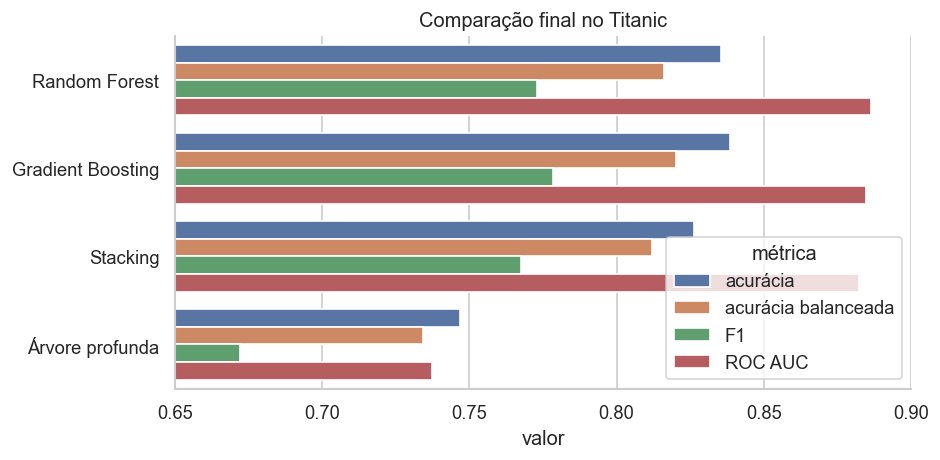

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = comparison_titanic.melt(
    id_vars='modelo',
    value_vars=['acurácia', 'acurácia balanceada', 'F1', 'ROC AUC'],
    var_name='métrica',
    value_name='valor',
)
sns.barplot(data=plot_df, x='valor', y='modelo', hue='métrica', ax=ax)
ax.set(title='Comparação final no Titanic', xlabel='valor', ylabel='')
ax.set_xlim(0.65, 0.9)
plt.tight_layout()
plt.show()


---
## Perguntas para discussão

1. Por que árvores profundas são um bom caso de uso para **bagging**?
2. Qual é a diferença conceitual entre combinar modelos por **votação/média**, por **soma sequencial** e por **meta-modelo**?
3. Por que o **Random Forest** tende a funcionar melhor do que bagging puro com árvores?
4. Em que sinal experimental você identificaria **overfitting** em boosting?
5. Em que situação você esperaria que **stacking** tivesse pouco ganho adicional?
6. Como o paralelo com Q-learning tabular vs aproximado ajuda a interpretar a diferença entre uma árvore isolada e um ensemble?
